In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests

from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

def calculate_vif(dataframe):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = dataframe.assign(constant=1)
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

major_celltypes = ['B cells',
       'CD4+ T cells', 'MAIT cells', 'Myeloid cells', 'NK cells',
        'TRAV1-2- CD8+ T cells', 'gd T cells']

# Inputs

In [2]:
# - coexp matrix 
coexp_adata = ad.read_h5ad('output/coexp_adata_sla_spearman_False.h5ad')
coexp_adata.obs[['age_donor','sample']] =  coexp_adata.obs['age_donor'].str.rsplit('_', n=1, expand=True)

# - add cell type ratio from the original deta to coexp adata obs
obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

cell_type_counts = obs.groupby(['age_donor', 'cell_type']).size().unstack(fill_value=0) #TODO: shorten cell types




if False: # ratios versus each other 
    cell_type_ratios = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0).reset_index()
else: # ratios versus each other 
    cell_type_ratios = cell_type_counts.div(cell_type_counts['CD4+ T cells'], axis=0).reset_index()
    
coexp_obs = coexp_adata.obs.merge(cell_type_ratios, on='age_donor', how='left')

# - extract sig links (targets)
sig_oo = pd.read_csv('output/links_pvalues_vs_34_sla_spearman_False.csv', index_col=0)

sig_oo['bonferroni'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='bonferroni')[1]
sig_oo['fdr'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='fdr_bh')[1]

mask = (sig_oo['fdr']<0.05)
sig_oo = sig_oo[mask]
sig_links = sig_oo.link.unique()
print('# of sig links',len(sig_links))
sig_oo.age_group.value_counts()

# of sig links 836


age_group
65_75    502
45_54    357
55_64    258
35_44    158
Name: count, dtype: int64

In [40]:

calculate_vif(cell_type_ratios[major_celltypes])

,feature,VIF
0,B cells,1.087861
1,CD4+ T cells,0.000000
2,MAIT cells,1.227122
3,Myeloid cells,1.655287
4,NK cells,1.565380
5,TRAV1-2- CD8+ T cells,1.075012
6,gd T cells,1.089734
7,constant,0.000000


# Cell type ratios across age groups

In [4]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
coexp_obs_df = coexp_obs[major_celltypes+['age_group']].set_index('age_group')
# Assuming df is your DataFrame with age groups as index and cell types as columns
df = coexp_obs_df

# Initialize a DataFrame to store p-values and mean comparisons
p_values = pd.DataFrame(index=df.columns, columns=df.index.unique())
mean_comparisons = pd.DataFrame(index=df.columns, columns=df.index.unique())

# Loop over each age group
for age_group in df.index.unique():
    print(age_group)
    # Loop over each cell type
    for cell_type in df.columns:
        # Define the test group and the background
        test_group = df.loc[age_group, cell_type]
        background = df.loc[df.index == '34-', cell_type]
        
        # Calculate means
        mean_test = test_group.mean()
        mean_background = background.mean()

        # Perform the Mann-Whitney U test
        _, p_value = mannwhitneyu(test_group.values, background.values, alternative='two-sided')
        
        # Store the p-value and mean comparison sign
        p_values.loc[cell_type, age_group] = p_value
        if mean_test > mean_background:
            mean_comparisons.loc[cell_type, age_group] = 1  # Positive change
        elif mean_test < mean_background:
            mean_comparisons.loc[cell_type, age_group] = -1  # Negative change
        else:
            mean_comparisons.loc[cell_type, age_group] = 0  # No change

# Reset index and melt the p-values DataFrame
p_values = p_values.reset_index().melt(id_vars='index', var_name='age_group', value_name='pvalue')
mean_comparisons = mean_comparisons.reset_index().melt(id_vars='index', var_name='age_group', value_name='mean_change')

# Calculate FDR for p-values
p_values['fdr'] = multipletests(p_values['pvalue'], method='bonferroni')[1]

# Merge FDR and mean change sign
results = pd.merge(p_values, mean_comparisons, on=['index', 'age_group'])

results['final_fdr'] = results['fdr'] * results['mean_change']
pivoted_results = results.pivot(index='index', columns='age_group', values='final_fdr')

# Display the pivoted results
print(pivoted_results)

65_75
55_64
45_54
35_44
34-
age_group             34-     35_44 45_54     55_64     65_75
index                                                        
B cells                 0        -1    -1 -0.614096 -0.146159
CD4+ T cells            0         1     1         1         1
MAIT cells              0        -1    -1 -0.000232 -0.000026
Myeloid cells           0         1     1        -1  0.016356
NK cells                0         1    -1         1  0.112202
TRAV1-2- CD8+ T cells   0        -1    -1 -0.107296      -0.0
gd T cells              0 -0.036455     1  0.021677 -0.000033


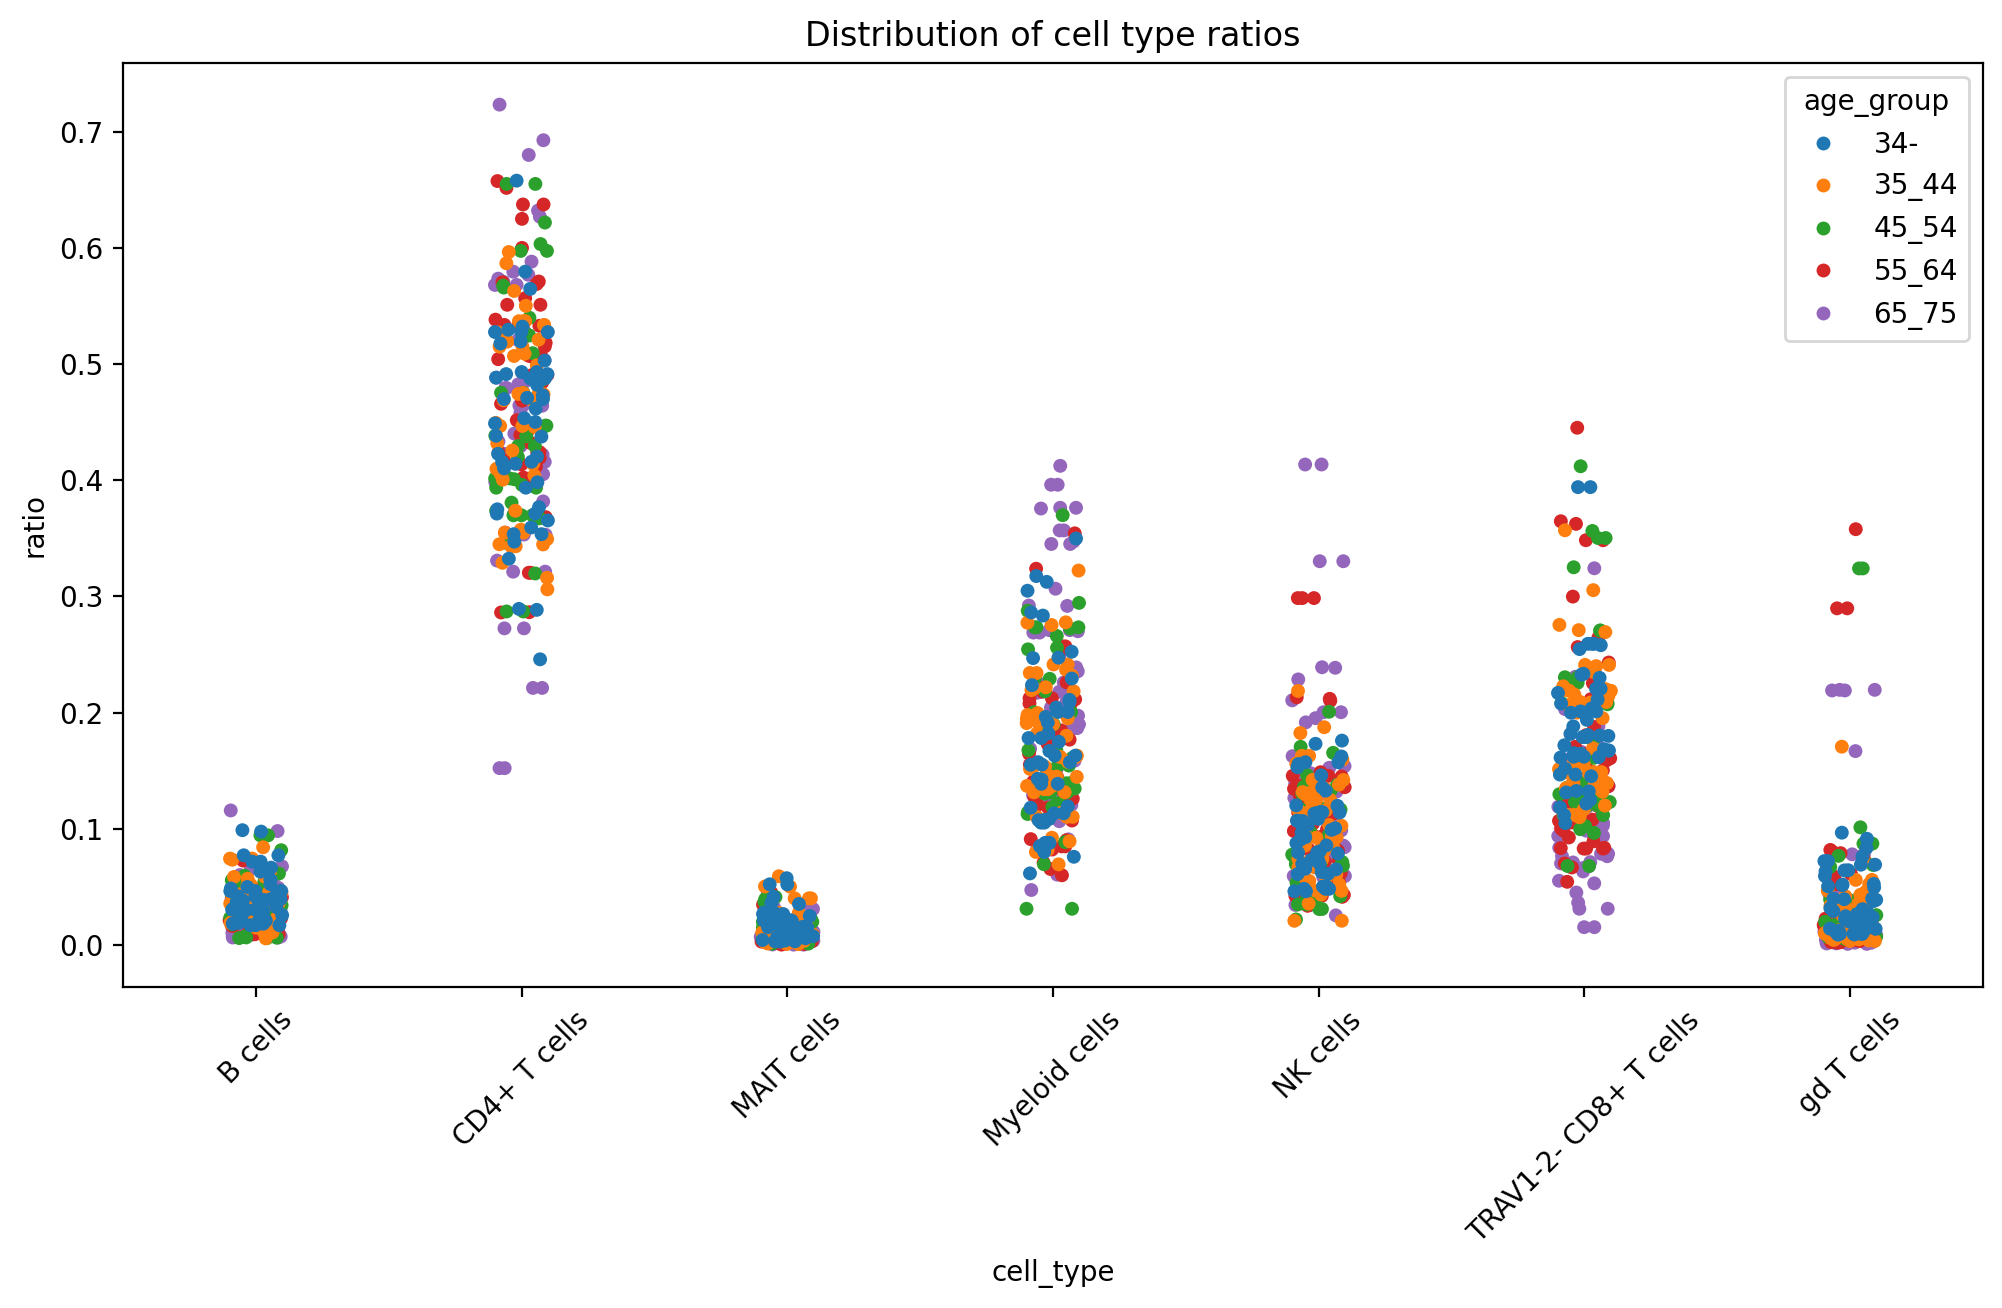

In [5]:
# Melt the DataFrame to long format for seaborn
df = coexp_obs_df
# df = df/df.max(axis=0)
df_long = df.reset_index().melt(id_vars='age_group', var_name='cell_type', value_name='ratio')

# Plot
plt.figure(figsize=(12, 6))
sns.stripplot(df_long, x='cell_type', y='ratio', hue='age_group')
plt.title('Distribution of cell type ratios')
plt.xticks(rotation=45)  # Rotate x-axis labels

plt.show()

# Cell type ratios predicts coexp

In [7]:
# - choose target for the reg (either sig links or a bigger space)
if False:
    target_links = np.unique(np.concatenate([np.random.choice(coexp_adata.var_names, 10000), sig_links]))
else:
    target_links = sig_links

In [8]:
# - run regression model
from src.helper import predict_celltype_ratio_from_coexp

if True:
    if True:
        # - prepare feature and target space 
        coexp_obs = coexp_obs[major_celltypes]
        coexp_obs.to_csv('output/feature_importances/X_df.csv')

        Y = coexp_adata.X[:, coexp_adata.var_names.isin(target_links)]
        Y_df = pd.DataFrame(Y, columns=target_links)
        Y_df.to_csv('output/feature_importances/Y_df.csv')

    if True:
        reg_type = 'ridge'
        predict_celltype_ratio_from_coexp(reg_type)
    else:
        reg_type = 'GB'
        !sbatch scripts/sbatch/helper.sh

100%|██████████| 836/836 [00:09<00:00, 85.73it/s]


In [9]:
# - retrieve results of regression analysis
reg_type = 'ridge'

r2_scores_df = pd.read_csv(f'output/feature_importances/r2_scores_df_{reg_type}.csv',index_col=0)
feature_importances_df = pd.read_csv(f'output/feature_importances/feature_importances_df_{reg_type}.csv', index_col=0)
# - normalize feature importance -> there should be no link with all features 0
assert (feature_importances_df==0).all(axis=0).sum() == 0
feature_importances_df = (feature_importances_df/feature_importances_df.abs().max(axis=0))

In [10]:
if False: # - r2 scores distribution
    fig, ax = plt.subplots(1,1, figsize=(2,2))
    # plot_cumulative_density(r2_scores_df_all.mean(axis=0), label='r2 scores (all)', ax=ax)
    plot_cumulative_density(r2_scores_df.mean(axis=0), label='r2 scores (sig)', ax=ax)

    plt.xlabel('r2 scores')
    plt.legend()

In [11]:
# - identify those links with low and high r2 scores
r2score_t = .1

low_scored_links = r2_scores_df.loc[:, r2_scores_df.mean()<r2score_t].columns
low_predicted_links = sig_oo[sig_oo.link.isin(low_scored_links)].link.values
print('low_predicted_links:', low_predicted_links.shape)

high_predicted_links = r2_scores_df.loc[:, r2_scores_df.mean()>r2score_t].columns
print('high_predicted_links:', high_predicted_links.shape)


low_predicted_links: (394,)
high_predicted_links: (595,)


In [12]:
# - subset feature importance to high predicted links
feature_importances_df = feature_importances_df[high_predicted_links]

In [13]:
feature_importances_df.sum(axis=1)

B cells                 -34.707692
CD4+ T cells              0.000000
MAIT cells                0.943201
Myeloid cells            78.654730
NK cells                -27.838932
TRAV1-2- CD8+ T cells   -19.671332
gd T cells               30.810895
dtype: float64

In [14]:
feature_importances_df.T.corr(method='spearman').style.background_gradient()

,B cells,CD4+ T cells,MAIT cells,Myeloid cells,NK cells,TRAV1-2- CD8+ T cells,gd T cells
B cells,1.000000,nan,-0.216688,-0.473042,0.266028,0.294979,0.173968
CD4+ T cells,nan,nan,nan,nan,nan,nan,nan
MAIT cells,-0.216688,nan,1.000000,0.382256,-0.219212,-0.197423,-0.236327
Myeloid cells,-0.473042,nan,0.382256,1.000000,-0.683384,-0.568900,-0.449841
NK cells,0.266028,nan,-0.219212,-0.683384,1.000000,0.630984,0.539049
TRAV1-2- CD8+ T cells,0.294979,nan,-0.197423,-0.568900,0.630984,1.000000,0.743732
gd T cells,0.173968,nan,-0.236327,-0.449841,0.539049,0.743732,1.000000


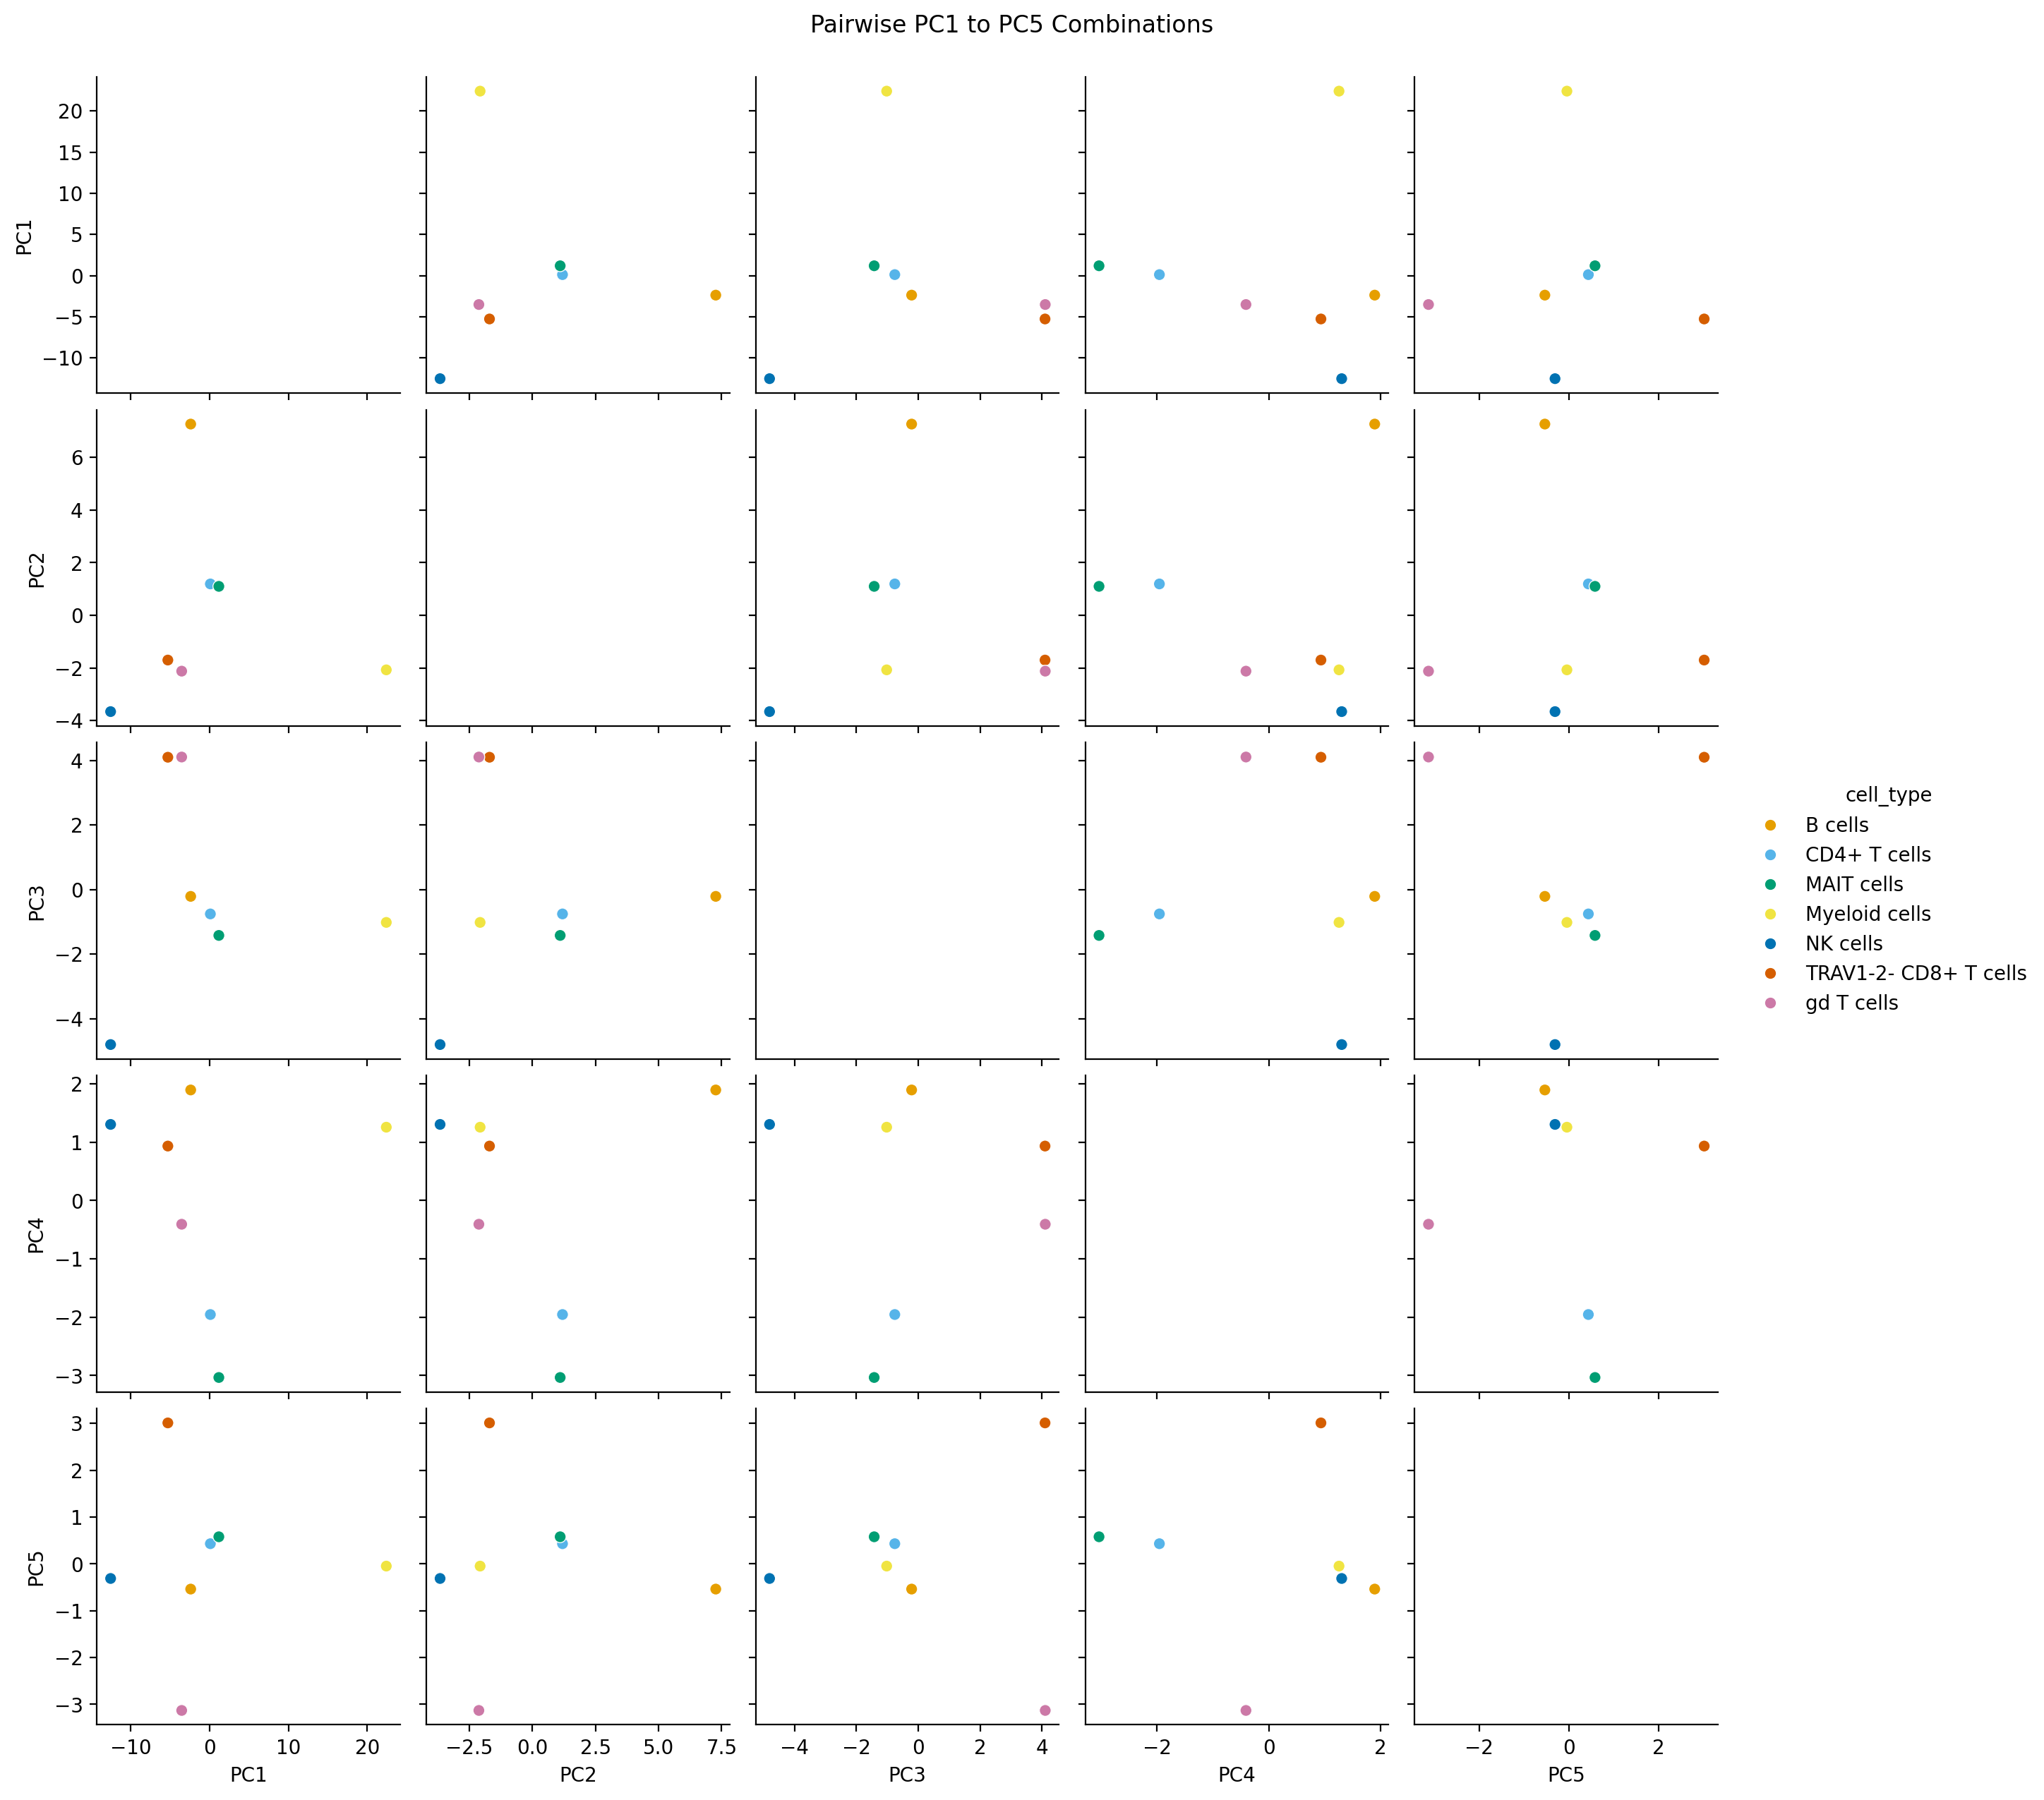

In [15]:
# - PCA analysis of feature importance
adata_feature_importance = ad.AnnData(feature_importances_df)
sc.pp.pca(adata_feature_importance, n_comps=5)

pca_df = pd.DataFrame(adata_feature_importance.obsm['X_pca'], columns=[f'PC{i+1}' for i in range(5)])

# - add cell type to the DataFrame
pca_df['cell_type'] = adata_feature_importance.obs.index
if True:
    # Create pairplot of all combinations of PC1 to PC6, colored by age_group
    sns.pairplot(pca_df, hue='cell_type', palette=colors_blind)  # You can choose any palette you prefer
    plt.suptitle("Pairwise PC1 to PC5 Combinations", y=1.02)
    plt.show()

In [16]:
# - analysis of loadings
pc_i = 0
top_loadings = 200

pc_loadings = pd.DataFrame({'share':adata_feature_importance.varm['PCs'][:, pc_i]}, index= adata_feature_importance.var_names)
pc_loadings.index.name = 'link'
pc_loadings = pc_loadings.sort_values(by='share', ascending=False, key=abs)

# - find out top loadings links
pc0_associated_links = pc_loadings.iloc[:top_loadings,].index
# - plot age specific distribution of feature importance 
if False:
    df = feature_importances_df[pc0_associated_links].reset_index().melt(id_vars='index', var_name='link', value_name='importance').rename(columns={'index':'feature'})

    for i, age_group in enumerate(['65_75']):
        df_sub = df[df.link.isin(sig_oo[sig_oo.age_group==age_group].link)]
        # feature_importances_long_f = feature_importances_long
        plt.figure(figsize=(5, 3))
        sns.stripplot(data=df_sub, x='feature', y='importance')
        plt.xticks(rotation=45)
        plt.title(f"{age_group}")
        plt.show()

In [17]:
sig_oo['link_type'] = 'others'
sig_oo.loc[sig_oo['link'].isin(low_predicted_links), 'link_type'] = 'low_predicted'
sig_oo.loc[sig_oo['link'].isin(pc0_associated_links), 'link_type'] = 'pc0_associated_links'

In [18]:
aaa

NameError: name 'aaa' is not defined

# Verification 

In [32]:
# - calculate new corr based on all donors for the target links -> age_group and cell_type specific (-1 means all cell types included)
if True:
    if False:
        adata = ad.read_h5ad('input/dataset_1_corrected_batch1.h5ad')

        # - target genes 
        sig_oo[['g1', 'g2']] = sig_oo['link'].str.split('_', expand=True)
        target_genes = np.unique(sig_oo[['g1', 'g2']].values.flatten())
        target_genes.shape

        # - subset to target genes
        adata = adata[:, adata.var_names.isin(target_genes)]
        print(adata)
    if True: # calculate corelation  
        def calculate_targetted_coexp(adata, layer='counts'):
            i_all = 0
            cell_types = list(adata.obs.cell_type.unique()) + [-1] # include all cell types 
            for cell_type in cell_types:
                if cell_type == -1:
                    adata_celltype = adata.copy()
                else:
                    mask_cell_type = adata.obs.cell_type == cell_type
                    adata_celltype = adata[mask_cell_type]
                for age_group in adata.obs.age_group.unique():
                    adata_age_group= adata_celltype[adata_celltype.obs.age_group==age_group]
                    
                    # - qc 
                    adata_age_group = basic_qc(adata_age_group, min_cells_per_gene=100, min_genes_per_cell=10)

                    if adata_age_group.shape[1] == 0: # those without any gene left after filtering
                        continue

                    # - normalize
                    X_norm = sc.pp.normalize_total(adata_age_group, layer=layer, inplace=False)['X']
                    X_norm = sc.pp.log1p(X_norm, copy=True)

                    try:
                        X_norm = X_norm.todense().A
                    except:
                        X_norm = X_norm
                    
                
                    corr_matrix, p_values = spearmanr(X_norm, nan_policy='raise')
                
                    # - correct the p value
                    p_values_flat = p_values.flatten()
                    _, p_values_corrected_flat, _, _ = multipletests(p_values_flat, method='fdr_bh')
                    p_values_corrected = p_values_corrected_flat.reshape(p_values.shape)

                    mask_non_sig =  p_values_corrected>=0.05
                    corr_matrix[mask_non_sig] = 0

                    # - melt
                    net = efficient_melting(corr_matrix, adata_age_group.var_names)

                    net['link'] = ['_'.join(sorted([str(src), str(tgt)])) for src, tgt in zip(net.source, net.target)]

                    # Create a MultiIndex from the specified columns in adata_age_donor
                    index_df = pd.DataFrame({'age_group':[age_group], 'cell_count': [len(adata_age_group)], 'cell_type': [cell_type]})
                    index = pd.MultiIndex.from_frame(index_df, names=['age_group', 'cell_count', 'cell_type'])

                    # Create a DataFrame with weights using the new 'link' and the MultiIndex
                    coexp_df = pd.DataFrame([net.weight.values], 
                                        columns=net.link, index=index)

                    if i_all == 0:
                        coexp_all = coexp_df
                    else:
                        coexp_all = pd.concat([coexp_all, coexp_df], axis=0)
                    i_all += 1
            return coexp_all
        if False: # using original data
            coexp_all = calculate_targetted_coexp(adata)
            coexp_all.to_csv('output/verification/coexp_all.csv')
        else: # using batch corrected data
            coexp_all = calculate_targetted_coexp(adata, layer='combat_corrected')
            coexp_all.to_csv('output/verification/coexp_all_bc.csv')

shape before  (32815, 157)
shape after  (32815, 156)
shape before  (47164, 157)
shape after  (47164, 156)
shape before  (38150, 157)
shape after  (38150, 156)
shape before  (42985, 157)
shape after  (42985, 156)
shape before  (45615, 157)
shape after  (45615, 156)
shape before  (8173, 157)
shape after  (8173, 151)
shape before  (19467, 157)
shape after  (19467, 155)
shape before  (14591, 157)
shape after  (14591, 155)
shape before  (18637, 157)
shape after  (18637, 155)
shape before  (20910, 157)
shape after  (20910, 155)
shape before  (64, 157)
shape after  (64, 0)
shape before  (67, 157)
shape after  (67, 0)
shape before  (51, 157)
shape after  (51, 0)
shape before  (97, 157)
shape after  (97, 0)
shape before  (78, 157)
shape after  (78, 0)
shape before  (568, 157)
shape after  (568, 100)
shape before  (1731, 157)
shape after  (1731, 137)
shape before  (3646, 157)
shape after  (3646, 147)
shape before  (1215, 157)
shape after  (1215, 131)
shape before  (3869, 157)
shape after  (3869,

In [33]:
# - retreieve the results 
coexp_all = pd.read_csv('output/verification/coexp_all_bc.csv')
coexp_all.head()

,age_group,cell_count,cell_type,ATP6V0B_LCK,LCK_TXNIP,CTSS_LCK,LCK_THEM4,LCK_S100A10,LCK_S100A4,ID2_LCK,...,FCN1_MARCKS,MARCKS_TNFRSF1A,LGALS3_MARCKS,CCL4_MARCKS,MARCKS_PLAUR,CFP_MARCKS,LEF1_MARCKS,KLRD1_MARCKS,MARCKS_SYTL2,ITGA6_MARCKS
0,65_75,32815,CD4+ T cells,0.023886,-0.023467,0.020378,0.026462,0.000000,-0.016353,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55_64,47164,CD4+ T cells,0.028447,-0.017535,0.027519,0.022042,0.000000,-0.016020,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,45_54,38150,CD4+ T cells,0.024279,0.000000,0.012442,0.015641,-0.013912,-0.019432,-0.022814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,35_44,42985,CD4+ T cells,0.013049,-0.018167,0.010605,0.000000,0.000000,-0.034615,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,34-,45615,CD4+ T cells,0.022736,0.000000,0.000000,0.000000,-0.024507,-0.030950,0.010720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


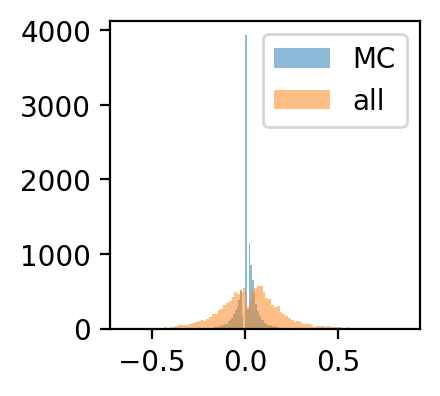

In [34]:
if True:
    # - correlation reduces considerbaly by looking at one cell type -> could be confounded by sample size 
    fig = plt.figure(figsize=(2,2))
    aa = plt.hist(coexp_all[(coexp_all.age_group=='65_75') & (coexp_all.cell_type=='Myeloid cells')].drop(columns=['age_group','cell_count','cell_type']).reset_index(drop=True).values.flatten(), bins=100, label='MC', alpha=.5)
    aa = plt.hist(coexp_all[(coexp_all.age_group=='65_75') & (coexp_all.cell_type=='-1')].drop(columns=['age_group','cell_count','cell_type']).reset_index(drop=True).values.flatten(), bins=100, label='all', alpha=.5)
    plt.legend()

In [35]:
# - verify 
age_group = '65_75'
cell_type = '-1' #'Myeloid cells'
link_type = 'low_predicted' #pc0_associated_links
coexp_all_sub = coexp_all[(coexp_all.age_group=='65_75') & (coexp_all.cell_type==cell_type)].drop(columns=['age_group','cell_count','cell_type']).reset_index(drop=True) - coexp_all[(coexp_all.age_group=='34-') & (coexp_all.cell_type==cell_type)].drop(columns=['age_group','cell_count','cell_type']).reset_index(drop=True)
discovery_table = sig_oo.loc[(sig_oo['age_group'].eq(age_group)) & (sig_oo['link_type'].eq(link_type))].pivot(index='age_group', columns='link', values='diff')
# pd.concat([discovery_table, coexp_all_sub], join='inner')
(pd.concat([discovery_table, coexp_all_sub], join='inner')>0).T.corr()
# (((pd.concat([discovery_table, coexp_all_sub], join='inner')>0).sum(axis=0)==0)|((pd.concat([discovery_table, coexp_all_sub], join='inner')>0).sum(axis=0)==2)).sum()

,65_75,0
65_75,1.0,1.0
0,1.0,1.0


In [36]:
(pd.concat([discovery_table, coexp_all_sub], join='inner')).T.corr()

,65_75,0
65_75,1.00000,0.95565
0,0.95565,1.00000


In [37]:
# - to be documented
coexp_all = coexp_all[target_links]
coexp_all = coexp_all[coexp_all.index.get_level_values('cell_type').isin(major_celltypes+[-1])]
# Assuming `df` is your DataFrame with a MultiIndex of (cell_type, age_group)
df = coexp_all.copy()
# Step 1: Separate the reference group
reference_group = df.loc[df.index.get_level_values('age_group')=='34-']

# Step 2: Define a function to calculate the difference from the reference
def calculate_difference(group):
    cell_type = group.index.get_level_values('cell_type')[0]
    # - get the data of the cell type from the reference.
    ref_celltype = reference_group.xs(cell_type, level='cell_type')
    # - adjust columns (sanity)
    ref_celltype = ref_celltype[group.columns]
    # - to match the index on age_group, repeat ref with the number of age groups 
    age_groups = group.index.get_level_values('age_group')
    ref_celltype_m = ref_celltype.loc[ref_celltype.index.repeat(len(age_groups))].reset_index(drop=True)
    ref_celltype_m.index = age_groups

    diff = group - ref_celltype_m

    return diff

differences = df.groupby(level='cell_type', group_keys=False).apply(calculate_difference)
differences = differences.loc[differences.index.get_level_values('age_group')!='34-', :]

KeyError: 'Requested level (cell_type) does not match index name (None)'

In [211]:
corr  = differences.T.corr()
np.fill_diagonal(corr.values, np.nan)
corr.style.background_gradient()

,,age_group,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44,65_75,55_64,45_54,35_44
,,cell_count,32815,47164,38150,42985,8173,19467,14591,18637,568,1731,3646,1215,492,925,1073,1092,1989,2633,3569,4051,13633,12980,7678,8236,17459,15993,13094,15554,75248,101048,81919,91918
,,cell_type,CD4+ T cells,CD4+ T cells,CD4+ T cells,CD4+ T cells,TRAV1-2- CD8+ T cells,TRAV1-2- CD8+ T cells,TRAV1-2- CD8+ T cells,TRAV1-2- CD8+ T cells,gd T cells,gd T cells,gd T cells,gd T cells,MAIT cells,MAIT cells,MAIT cells,MAIT cells,B cells,B cells,B cells,B cells,NK cells,NK cells,NK cells,NK cells,Myeloid cells,Myeloid cells,Myeloid cells,Myeloid cells,-1,-1,-1,-1
age_group,cell_count,cell_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
65_75,32815,CD4+ T cells,nan,0.588711,0.419084,0.414261,0.077280,0.106675,-0.040343,0.028593,-0.021460,0.273153,0.043227,0.186643,0.341145,-0.394342,-0.090053,0.167511,-0.087317,0.071856,0.042011,-0.130941,-0.036703,0.027544,-0.021199,-0.080179,0.185874,0.132521,0.200706,0.115395,0.206748,0.090453,0.000242,0.034195
55_64,47164,CD4+ T cells,0.588711,nan,0.403400,0.504862,-0.120860,0.056251,-0.227954,0.069189,-0.149289,-0.060914,-0.302116,0.300173,0.075758,-0.430922,-0.094999,0.383673,-0.250454,-0.081080,0.035146,-0.106012,-0.136871,-0.123768,-0.241942,0.003653,-0.017705,-0.027253,-0.024038,-0.090400,0.167112,0.222471,0.054022,0.054131
45_54,38150,CD4+ T cells,0.419084,0.403400,nan,0.274616,-0.036417,-0.083335,0.168582,-0.063717,-0.364469,-0.214089,-0.069170,-0.278260,0.073106,-0.121337,-0.058779,0.150876,-0.138760,-0.061864,0.045977,-0.020735,-0.117011,0.287605,0.206459,-0.066963,-0.024136,-0.028629,-0.060445,-0.092267,0.022467,0.217628,0.275670,0.171094
35_44,42985,CD4+ T cells,0.414261,0.504862,0.274616,nan,-0.323204,-0.206410,-0.318788,0.303937,0.071331,-0.192894,-0.402477,0.181150,0.143418,-0.209565,-0.105906,0.075306,-0.091108,0.057744,-0.021952,-0.125818,0.101582,-0.152758,-0.151086,0.045727,0.258388,0.217519,0.196345,0.096481,0.189867,0.096670,0.036877,0.229609
65_75,8173,TRAV1-2- CD8+ T cells,0.077280,-0.120860,-0.036417,-0.323204,nan,0.669007,0.605531,0.139542,0.417791,0.528629,0.586030,0.357744,0.430106,0.303397,0.210339,-0.111093,0.205941,0.112352,0.037451,0.269831,0.158964,0.116653,0.182763,0.094054,-0.095403,-0.061111,-0.073487,0.071382,0.066264,0.072500,-0.060345,-0.108448
55_64,19467,TRAV1-2- CD8+ T cells,0.106675,0.056251,-0.083335,-0.206410,0.669007,nan,0.377195,0.194320,0.193193,0.430478,0.304140,0.417498,-0.195895,-0.227553,0.048393,0.221396,-0.110905,0.009533,-0.049722,0.229344,-0.102248,-0.242045,-0.185055,0.042360,-0.105878,-0.068205,-0.174470,-0.042871,0.195475,0.155170,-0.079056,-0.002873
45_54,14591,TRAV1-2- CD8+ T cells,-0.040343,-0.227954,0.168582,-0.318788,0.605531,0.377195,nan,0.245460,-0.010151,0.199284,0.554788,-0.029388,0.278738,0.426415,0.278579,-0.062860,0.218392,0.063273,0.091606,0.334653,-0.031916,0.318663,0.360555,-0.025549,-0.036999,-0.029948,-0.052300,0.066281,-0.053298,0.111273,0.154192,0.069125


In [214]:
differences_sub = differences.xs(-1, level='cell_type').xs('65_75', level='age_group')
df_merged = pd.concat([differences_sub, discovery_table], axis=0, join='inner')
df_merged.T.corr()

,75248,65_75
75248,1.000000,0.952719
65_75,0.952719,1.000000


In [215]:
df_merged_sign = df_merged>0
df_merged_sign.T.corr()

,75248,65_75
75248,1.000000,0.986242
65_75,0.986242,1.000000


# Coexp predicts cell type ratio

In [16]:
save_tag = '_reversed'
target_links = sig_links

In [23]:
from src.helper import predict_celltype_ratio_from_coexp

if True:
    if True:
        # - prepare feature and target space 
        coexp_obs = coexp_obs[major_celltypes]
        coexp_obs.to_csv('output/feature_importances/Y_df.csv')

        Y = coexp_adata.X[:, coexp_adata.var_names.isin(target_links)]
        Y_df = pd.DataFrame(Y, columns=target_links)
        Y_df.to_csv('output/feature_importances/X_df.csv')

    if True:
        reg_type = 'ridge'
    else:
        reg_type = 'GB'
    predict_celltype_ratio_from_coexp(reg_type, save_tag=save_tag)

100%|██████████| 7/7 [00:00<00:00, 23.06it/s]


In [17]:
reg_type = 'ridge'

r2_scores_df = pd.read_csv(f'output/feature_importances/r2_scores_df_{reg_type}{save_tag}.csv',index_col=0)
feature_importances_df = pd.read_csv(f'output/feature_importances/feature_importances_df_{reg_type}{save_tag}.csv', index_col=0)
# feature_importances_df = feature_importances_df.div(feature_importances_df.abs().max(axis=0))
# - normalize feature importance -> there should be no link with all features 0
# assert (feature_importances_df==0).all(axis=0).sum() == 0
# feature_importances_df = (feature_importances_df/feature_importances_df.abs().max(axis=0))

In [18]:
r2_scores_df

,B cells,CD4+ T cells,MAIT cells,Myeloid cells,NK cells,TRAV1-2- CD8+ T cells,gd T cells
0,0.912385,0.833907,0.488849,0.963358,0.900187,0.660775,0.841578
1,0.934017,0.822645,0.489616,0.959923,0.942097,0.559395,0.206283
2,0.928089,0.815819,0.156232,0.972898,0.909849,0.588279,0.737106
3,0.866806,0.743315,0.232117,0.964271,0.890554,0.425734,0.749076
4,0.928682,0.928417,0.374817,0.967034,0.941742,0.709320,0.726296


In [18]:
t_variance = .5
for cell_type in feature_importances_df.columns:

    df_sorted = feature_importances_df[cell_type].sort_values(key=abs, ascending=False)
df_sorted.abs().cumsum()

    df_sorted
    aa

NameError: name 'aa' is not defined

HLA-DRA_RPSA         0.001239
HLA-DPA1_HLA-DRB1    0.002424
HLA-DRA_TCIRG1       0.003496
CFP_HLA-DRA          0.004519
ARPC3_S100A4         0.005483
                       ...   
ATP6V0C_RPSA         0.186277
HLA-C_HLA-E          0.186279
KLF4_PTEN            0.186280
DGKA_HINT1           0.186280
CTSS_RALB            0.186280
Name: B cells, Length: 836, dtype: float64

In [25]:
import pandas as pd
import numpy as np


# Function to calculate VIF


# Calculate VIF
vif_results = calculate_vif(Y_df)
print(vif_results)

          feature  VIF
0        LCK_RHOB  inf
1        IL7R_LCK  inf
2        CD83_LCK  inf
3     HLA-DRA_LCK  inf
4    HLA-DRB1_LCK  inf
..            ...  ...
832    CFP_FKBP1A  inf
833     CEBPB_CFP  inf
834      CFP_SAT1  inf
835     CFP_IL2RG  inf
836      constant  0.0

[837 rows x 2 columns]


In [31]:
vif_results['VIF'][(vif_results['VIF']==np.inf)]=0
vif_results['VIF'].max()

0.0

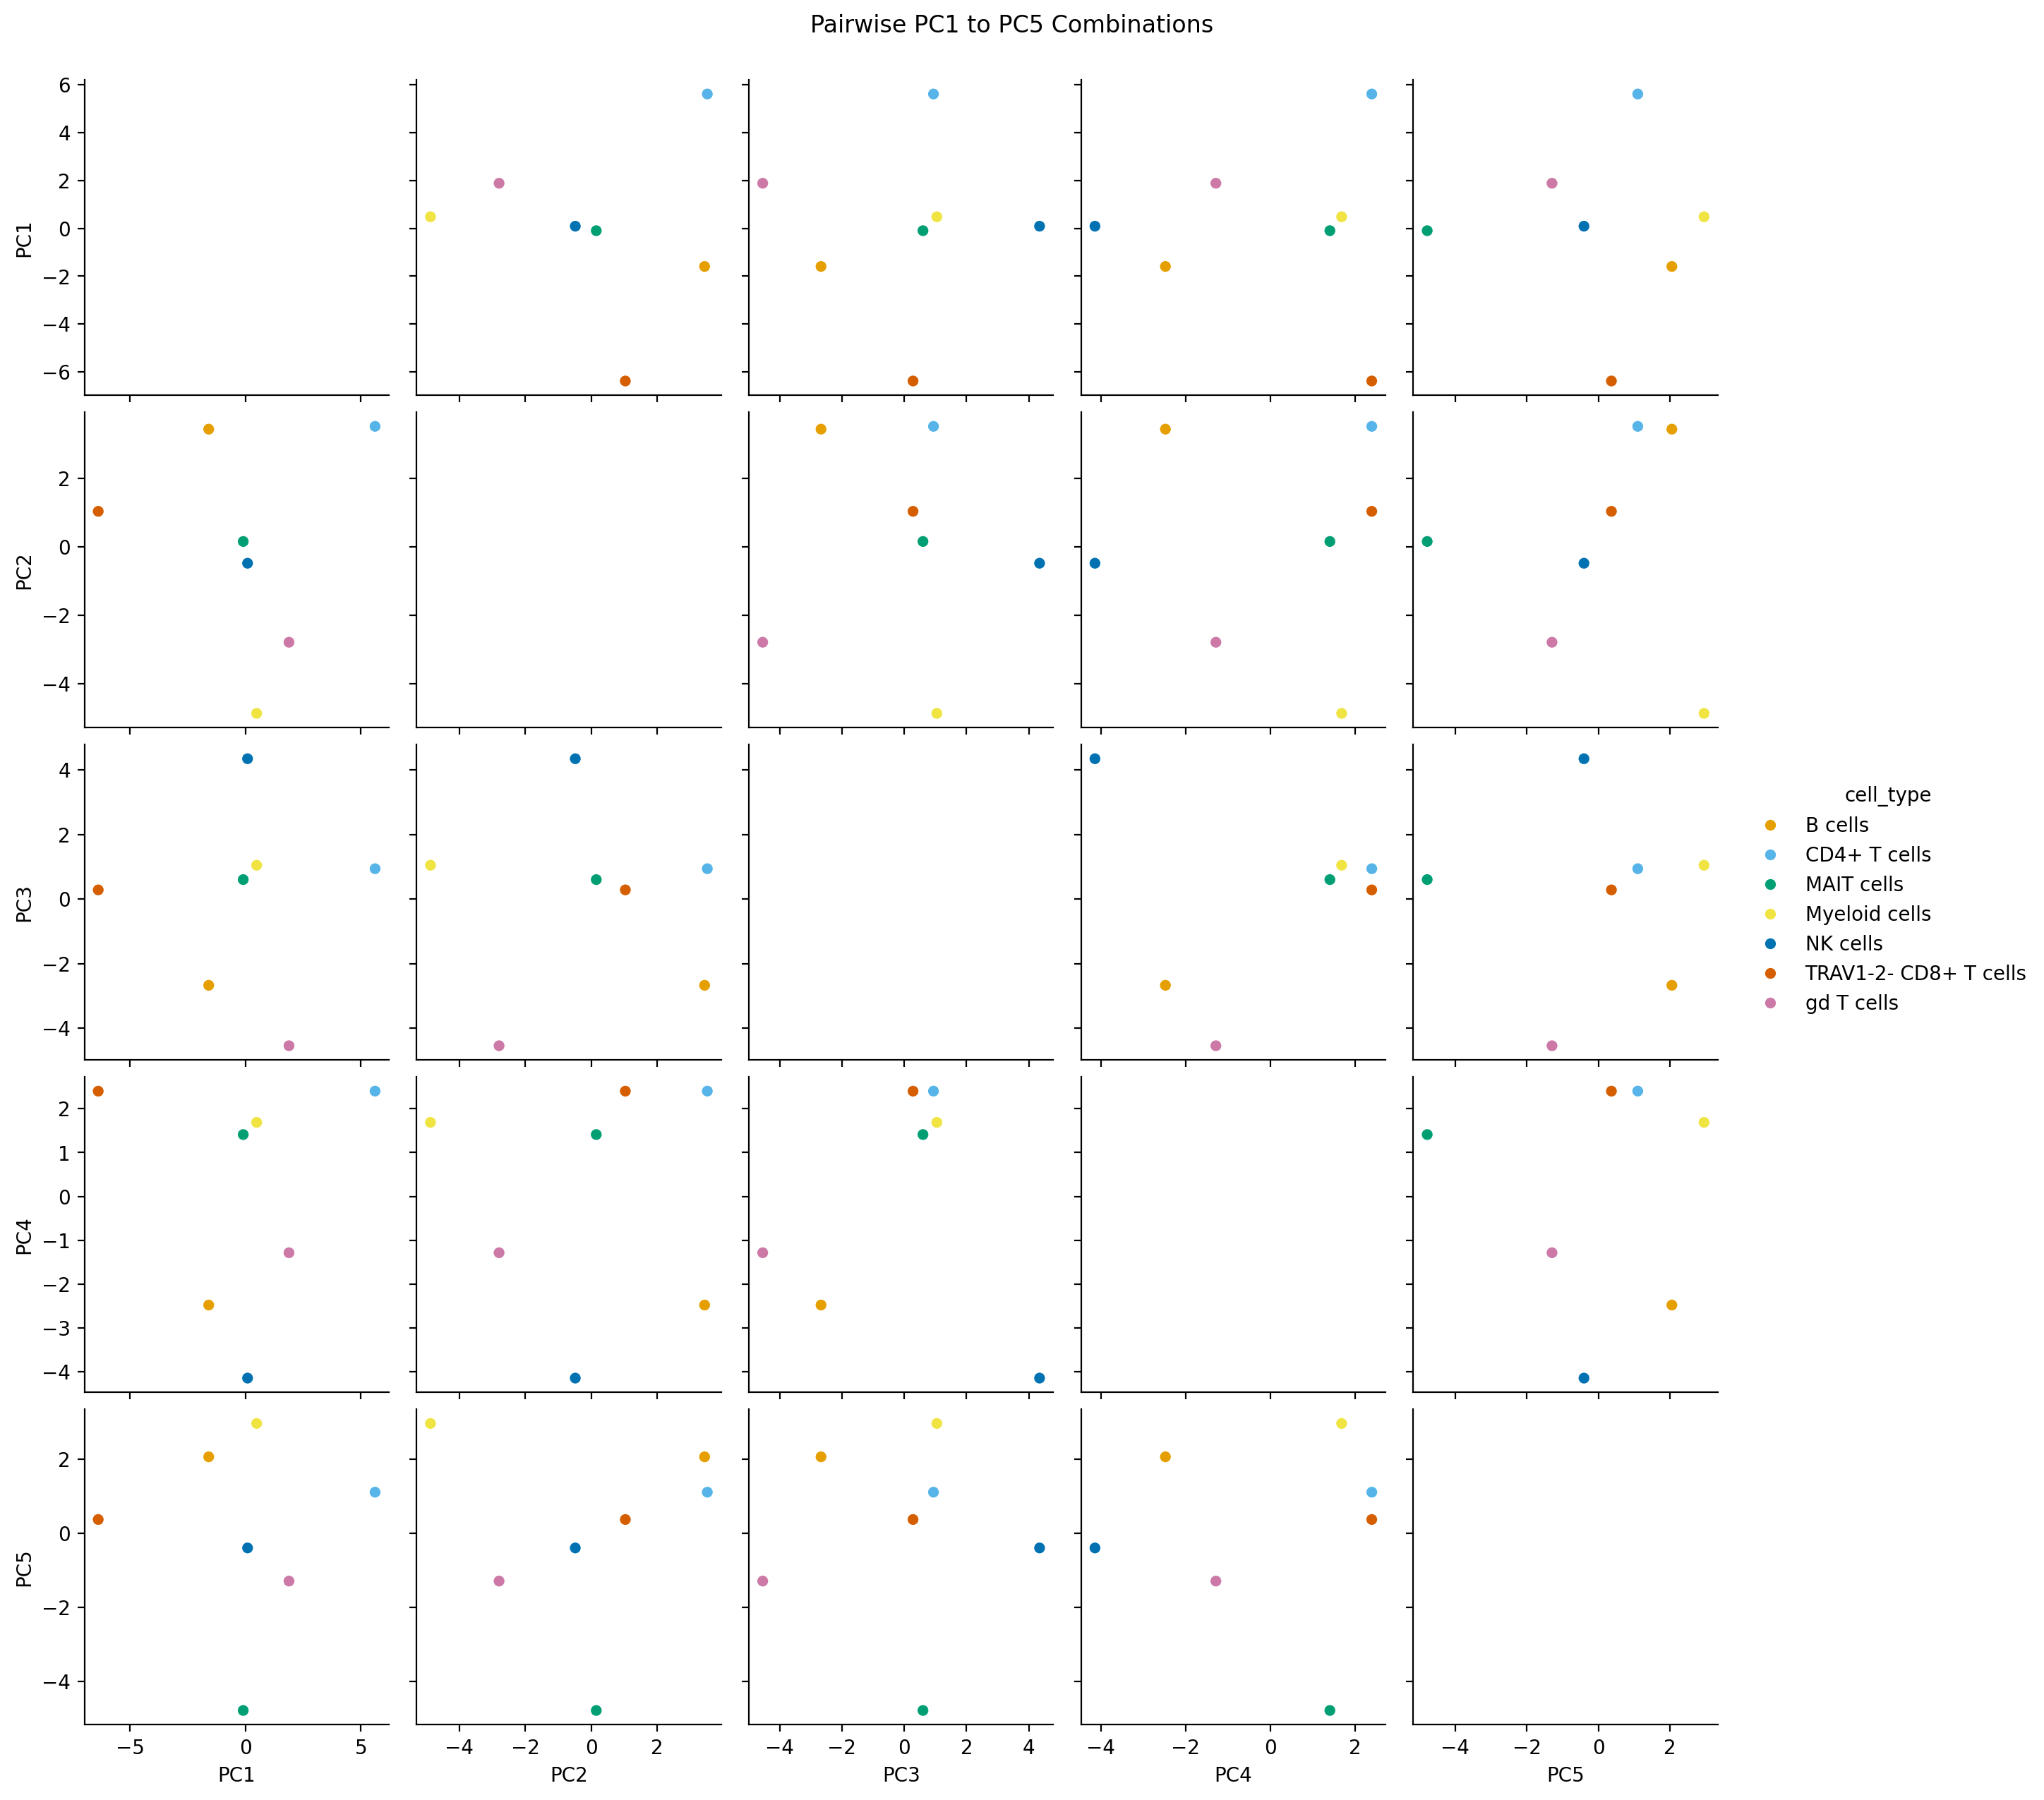

In [7]:

# - PCA analysis of feature importance
adata_feature_importance = ad.AnnData(feature_importances_df.T)
sc.pp.pca(adata_feature_importance, n_comps=5)

pca_df = pd.DataFrame(adata_feature_importance.obsm['X_pca'], columns=[f'PC{i+1}' for i in range(5)])

# - add cell type to the DataFrame
pca_df['cell_type'] = adata_feature_importance.obs.index
if True:
    # Create pairplot of all combinations of PC1 to PC6, colored by age_group
    sns.pairplot(pca_df, hue='cell_type', palette=colors_blind)  # You can choose any palette you prefer
    plt.suptitle("Pairwise PC1 to PC5 Combinations", y=1.02)
    plt.show()